Imports

In [1]:
import pickle as pkl
import numpy as np
import json
from os.path import sep
import cv2
from glob import glob
import matplotlib
import matplotlib.pyplot as plt
import select_files
import scienceplots
from scipy.interpolate import interp1d
from generate_training import modelist
import power_length_analysis
import Meta_classifier

plt.style.use(['science', 'ieee', 'no-latex'])

plt.rcParams.update({
    'figure.figsize': [7.2, 7.2],
    'font.size': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300
})


# Open and format data

In [2]:
# t_stamps = ['20240731_152730', '20240731_155505']

t_chunks = [
    ['20240801_113356', '20240801_121612'],
    ['20240801_122939','20240801_131044'],
    ['20240801_132209','20240801_140231'],
    ['20240801_141244', '20240801_143545'],
    ['20240801_145012','20240801_152128']
    ]

# t_chunks = [
#     ['20240730_124313', '20240730_135435'],
#     ['20240730_141105', '20240730_151123'],
#     ['20240730_151808', '20240730_161932'],
#     ['20240730_163444', '20240730_172003'],
#     ['20240730_175911', '20240730_184501'],
#     ['20240730_215344', '20240730_230915'],
#     ['20240730_232357', '20240731_005200'],
#     ]

image_dir = r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data'
crop_dir = r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data\Cropped_Images\22_07_disp_1_crop'
files, metas = select_files.open_img_files(t_chunks, image_dir)


In [3]:
bec_file = r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data\20240722\pbec_20240722_155609_1511.0_0.04657894736842105_956.7977294921875_-1.0_.png'
power_length_analysis.bec_crop_centre(bec_file, files, [300,300], crop_dir)

In [4]:
print(len(files))
# files = np.array(glob(crop_dir  + sep + '*.png'))
print(len(files))
data = power_length_analysis.data_from_metas(metas, files)

523
523


# Threshold plot

In [5]:
# stim_mask = select_files.select_stimulated_nd(data)
# stim_mask = select_files.select_stimulated_exp(data, 5)
stim_mask = select_files.select_stimulated_exp_from_filename(data['file'], 10)


20240801121612
955.4125366210938
20240801131044
951.1298828125
20240801140231
938.7418212890625
20240801143545
933.5916137695312
20240801152128
925.7370300292969


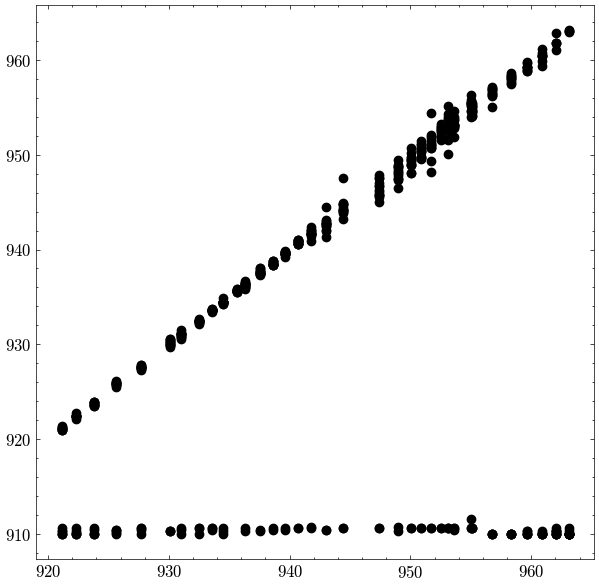

In [6]:


# Fit PCA values to cavity length
if 'pca' not in data.keys():
    print('!')
    png_data = power_length_analysis.data_dict(files)
    data.update({'pca': png_data['pca']})

pca_length = []

for i in t_chunks:
    # Creates mask for stimulated emission and each time cavity is locked
    mint = int(i[0].split('_')[0] + i[0].split('_')[1])
    maxt = int(i[1].split('_')[0] + i[1].split('_')[1])
    print(maxt)
    tmask = (mint <= data['t']) & (data['t'] <= maxt)
    mask = tmask & stim_mask


    # plt.scatter(data['cavity_length'][mask], data['power'][mask])
    # plt.show()

    mean_length = np.median(data['cavity_length'][mask])
    print(mean_length)
    length_mask = (mean_length - 10 <= data['cavity_length']) & (data['cavity_length']  <= mean_length + 10)
    mask = tmask & stim_mask & length_mask
    

    # plt.scatter(data['pca'][mask], data['cavity_length'][mask])
    # plt.show()
    # fits pca values to cavity length
    _, fit = power_length_analysis.fit_pca(data['cavity_length'][mask], data['pca'][mask])
    pca_length += list(fit(data['pca'][tmask]))



    x = np.linspace(min(data['pca'][mask]), max(data['pca'][mask]), 20)
    # plt.plot(x, fit(x))
    # plt.title(i)
    # plt.show()

data.update({'pca_length': np.array(pca_length)})


plt.scatter(data['pca_length'], data['cavity_length'])
plt.show()

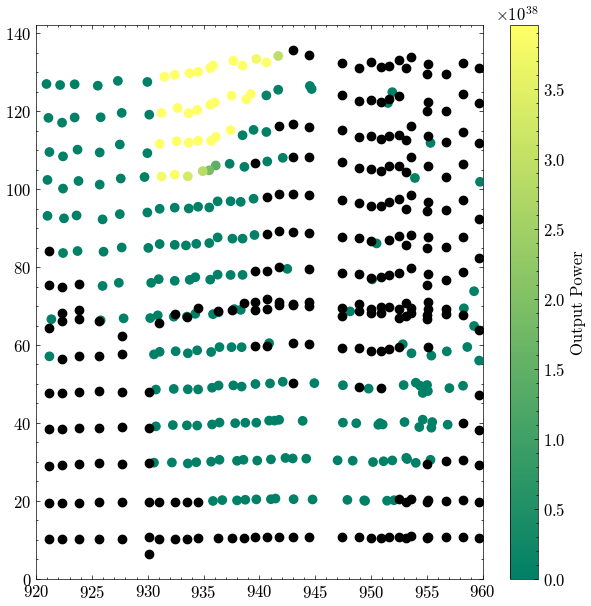

In [10]:
fig, ax = plt.subplots(1,1)
# Thermal cloud histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][~stim_mask],
#     data['power'][~stim_mask],
#     [910,970], [0,120],
#     'grey', 30, fig = fig, ax = ax, alpha = 1
# )

# # Stimulated emission histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][stim_mask],
#     data['power'][stim_mask],
#     [910,970], [0,120],
#     'orchid', 30, fig = fig, ax = ax, alpha= 1
# )

# print(data['pca_length'][stim_mask])

# Scattered points
scat = ax.scatter(data['cavity_length'][stim_mask], data['power'][stim_mask], c = data['meter_reading'][stim_mask], cmap= 'summer', label = 'Above Threshold')
ax.scatter(data['pca_length'][~stim_mask], data['power'][~stim_mask], color = 'black', label = 'Below Threshold')
ax.set_xlim([920,960])
cbar = fig.colorbar(scat, ax = ax, label = 'Output Power')
plt.show()

# Basic Clustering

Kmeans

In [ ]:
# Kmeans clustering on images
cluster_labels, _ = Meta_classifier.Kmeans_no_CNN(data['file'][stim_mask], 3)

# Plots each cluster
fig, ax, _, _ = power_length_analysis.all_cluster_plot(
    np.amax(cluster_labels), cluster_labels, 
    data['pca_length'][stim_mask], data['power'][stim_mask],
    'tab20b', 8, [945,960], [0,120], 8
)



Fuzzy CMeans

In [ ]:
mem_mat = Meta_classifier.quick_fcmeans(data['flat_image'][stim_mask], 3, 1.5, return_matrix=True)

In [ ]:
fig, axes, gs = power_length_analysis.grid_plot(3, 3,1, 0.5, 0.5)

for i, col in enumerate(mem_mat):

    power_length_analysis.plot_2dhist(
        data['pca_length'][~stim_mask],
        data['power'][~stim_mask],
        [930,960], [0,120],
        'grey', 10, fig = fig, ax = axes[i], alpha = 1
    )

    power_length_analysis.plot_2d_stat_hist(
        data['pca_length'][stim_mask],
        data['power'][stim_mask],
        col,
        [940,960], [0,120], bins = 10,
        cmap = 'viridis', fig = fig, ax = axes[i]
    )

# CNN

Make Predictions

In [ ]:
model_root = ''
save_path = ''
feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_mask], model_root, phases = 1)
outputs, preds = Meta_classifier.predeict_images_CNN(data['file'][stim_mask], model_root, phases = 1)

cnn_outs = {
    'feature_vectors': feat_vectors,
    'outputs': outputs,
    'predictions': preds
}

with open(save_path, 'w') as f:
    json.dump(f)


Confidence plot

In [ ]:
#Scale for all colorbars
vs = [np.min(preds), np.max(preds)]


fig, axes, gs = power_length_analysis.grid_plot(
    nplots = 3, ncols= 3, nrows=1, 
    wspace = 0.5, hspace = 0.5)

for i in range(cnn_outs['outputs'].shape[1]):
    mode_conf = cnn_outs['outputs'][:,i,0]
    _,_, plot, stat = power_length_analysis.plot_2d_stat_hist(data['pca_length'][stim_mask],
                                            data['power'][stim_mask],
                                            mode_conf, [940,960],
                                            [min(data['power']), max(data['power'])], bins = 10, cmap='Spectral_r',
                                            fig = fig, ax = axes[i], vs = vs, ret_stat=True) 